# prompt role cluster analysis

this notebook helps you turn the raw prompt corpus in `../data/prompts` plus the component coding in `../data/prompt_components.csv` into a reusable cluster map for guided start.

it does four things:

1. reconstructs agent-level prompt text for each coded prompt
2. creates embeddings and searches for a reasonable cluster count
3. asks an llm to generate a human-readable centroid label for each cluster
4. computes the component profile for each cluster and exports source-of-truth artifacts

expected outputs:

- `../data/analysis_outputs/agent_prompt_dataset.csv`
- `../data/analysis_outputs/cluster_assignments.csv`
- `../data/analysis_outputs/cluster_overview.csv`
- `../data/analysis_outputs/cluster_component_profiles.csv`
- `../data/analysis_outputs/guided_start_cluster_cards.json`

this notebook assumes you have an `OPENAI_API_KEY` available in your environment.

In [5]:
!pip install openai pandas numpy scikit-learn matplotlib seaborn

  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 61.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 79.9 MB/s  0:00:00
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 45.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 102.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 74.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 104.9 MB/s  0:00:00
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 27.6 MB/s  0:00:00
Using cached idna-3.11-py3-none-any.whl (71 kB)
   ━━━━━━━━━━━━━━

In [6]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from openai import OpenAI
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid")

EMBEDDING_MODEL = "text-embedding-3-large"
EXTRACTION_MODEL = "gpt-4.1-mini"
LABEL_MODEL = "gpt-5.4"

MIN_CLUSTERS = 4
MAX_CLUSTERS = 14
COMPONENT_MIN_RATE = 0.60
COMPONENT_MIN_LIFT = 1.05
EXTRACTION_CHAR_LIMIT = 250_000
EMBEDDING_CHAR_LIMIT = 4000
EXTRACTION_AGENT_BATCH_SIZE = 3
MAX_JSON_REPAIR_ATTEMPTS = 2
BATCH_SIZE = 32

REBUILD_EXTRACTIONS = False
REBUILD_EMBEDDINGS = False
REBUILD_CLUSTER_LABELS = False

# run this once if you need notebook deps
# %pip install openai pandas numpy scikit-learn matplotlib seaborn

In [7]:
ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "component_analysis",
    Path.cwd().parent / "component_analysis",
]
PROJECT_MATCHES = [path.resolve() for path in ROOT_CANDIDATES if (path / "data" / "prompt_components.csv").exists()]
assert PROJECT_MATCHES, "could not locate the component_analysis directory"
PROJECT_DIR = PROJECT_MATCHES[0]

DATA_DIR = PROJECT_DIR / "data"
PROMPTS_DIR = DATA_DIR / "prompts"
COMPONENTS_PATH = DATA_DIR / "prompt_components.csv"
CACHE_DIR = DATA_DIR / "analysis_cache"
OUTPUT_DIR = DATA_DIR / "analysis_outputs"
EXTRACTIONS_CACHE_PATH = CACHE_DIR / "extracted_agent_prompts.json"
EMBEDDINGS_CACHE_PATH = CACHE_DIR / "prompt_embeddings.npy"
EMBEDDINGS_META_PATH = CACHE_DIR / "prompt_embeddings_meta.json"
LABELS_CACHE_PATH = CACHE_DIR / "cluster_labels.json"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COMPONENT_COLUMNS = [
    "role_description",
    "context",
    "tool_definitions",
    "input",
    "actions",
    "security_disclaimer",
    "constraints_restrictions",
    "task_description_workflow",
    "in_context_examples",
    "output",
    "external_information",
    "placeholder",
]


def clip_text(text: str, limit: int = 320) -> str:
    collapsed = " ".join(str(text).split())
    return collapsed[: limit - 1] + "..." if len(collapsed) > limit else collapsed


def component_label(name: str) -> str:
    return name.replace("_", " ")


def fingerprint_records(df: pd.DataFrame, columns: list[str]) -> str:
    payload = "\n".join(df[columns].astype(str).agg(" || ".join, axis=1).tolist())
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


components_df = pd.read_csv(COMPONENTS_PATH)
missing_component_columns = [column for column in COMPONENT_COLUMNS if column not in components_df.columns]
assert not missing_component_columns, f"missing component columns: {missing_component_columns}"
assert not components_df.duplicated(subset=["repo_name", "agent_name"]).any(), "duplicate repo_name/agent_name rows found in prompt_components.csv"
for column in COMPONENT_COLUMNS:
    components_df[column] = components_df[column].fillna(0).astype(int)

prompt_files = {
    path.parent.name: path.read_text(encoding="utf-8", errors="replace")
    for path in sorted(PROMPTS_DIR.glob("*/prompts.txt"))
}
prompt_file_hashes = {
    repo_name: hashlib.sha256(text.encode("utf-8")).hexdigest()
    for repo_name, text in prompt_files.items()
}
missing_prompt_files = sorted(set(components_df["repo_name"]) - set(prompt_files))
assert not missing_prompt_files, f"missing prompts.txt for repos: {missing_prompt_files}"

print(f"project_dir: {PROJECT_DIR}")
print(f"prompt files: {len(prompt_files)}")
print(f"coded prompts: {len(components_df)}")

display(components_df.head())

project_dir: /Users/leoxu/codeground/MAS/component_analysis
prompt files: 27
coded prompts: 268


,repo_name,agent_name,role_description,context,tool_definitions,input,actions,security_disclaimer,constraints_restrictions,task_description_workflow,in_context_examples,output,external_information,placeholder,extra_codes
0,Deluxer_oliva,ASSISTANT_SYSTEM - Main AI Assistant Role,1,0,0,0,1,0,1,0,0,0,0,0,NaN
1,Deluxer_oliva,GRADE_DOCUMENTS_PROMPT - Document Relevance Grader (Primary Version),1,0,0,1,0,0,1,1,0,1,0,1,NaN
2,Deluxer_oliva,GRADE_DOCUMENTS_PROMPT_OPT_2 - Document Relevance Grader (Alternative Version),1,0,0,1,0,0,0,1,1,1,0,1,NaN
3,Deluxer_oliva,BLOG_SEARCH_PROMPT - Blog Search Assistant,1,0,1,0,1,0,0,0,0,0,0,0,NaN
4,Deluxer_oliva,AMAZON_SEARCH_PROMPT - Product Search Assistant,1,0,1,0,1,0,1,0,0,0,0,0,NaN


In [ ]:
EXTRACTION_SYSTEM_PROMPT = """
you reconstruct prompt-level records from a repository-level prompt dump.

you will receive:
- a repo name
- a list of agent names that must appear exactly once in the output
- the raw prompt file text for that repo

your job:
- match each provided agent name to the best corresponding prompt content in the file
- return the most relevant prompt span for that agent
- preserve the original wording from the file as much as possible
- if a prompt cannot be confidently isolated, return the best available excerpt instead of leaving it empty

return json only in the shape:
{
  "agents": [
    {
      "agent_name": "exact string from provided list",
      "prompt_text": "matched prompt text"
    }
  ]
}
""".strip()

JSON_REPAIR_SYSTEM_PROMPT = """
you repair malformed json.

return only valid json.
do not summarize, do not explain, do not drop requested objects.
""".strip()


def chunk_list(values: list[str], size: int) -> list[list[str]]:
    return [values[start:start + size] for start in range(0, len(values), size)]


def parse_json_with_repair(client: OpenAI, content: str, context_label: str) -> dict:
    last_error = None
    candidate = content

    for attempt in range(MAX_JSON_REPAIR_ATTEMPTS + 1):
        try:
            return json.loads(candidate)
        except json.JSONDecodeError as error:
            last_error = error
            if attempt == MAX_JSON_REPAIR_ATTEMPTS:
                break
            repair_payload = {
                "context": context_label,
                "invalid_json": candidate,
                "error": str(error),
            }
            repair_response = client.chat.completions.create(
                model=EXTRACTION_MODEL,
                temperature=0,
                response_format={"type": "json_object"},
                messages=[
                    {"role": "system", "content": JSON_REPAIR_SYSTEM_PROMPT},
                    {"role": "user", "content": json.dumps(repair_payload)},
                ],
            )
            candidate = repair_response.choices[0].message.content or ""

    raise ValueError(f"could not parse json for {context_label}: {last_error}")


def extract_repo_prompt_segments(client: OpenAI, repo_name: str, agent_names: list[str], prompt_file_text: str) -> list[dict]:
    assert len(prompt_file_text) <= EXTRACTION_CHAR_LIMIT, (
        f"{repo_name} prompt dump is too large for one extraction pass "
        f"({len(prompt_file_text)} chars > {EXTRACTION_CHAR_LIMIT})."
    )

    extracted = {}

    for agent_batch in chunk_list(agent_names, EXTRACTION_AGENT_BATCH_SIZE):
        payload = {
            "repo_name": repo_name,
            "agent_names": agent_batch,
            "prompt_file_text": prompt_file_text,
        }
        response = client.chat.completions.create(
            model=EXTRACTION_MODEL,
            temperature=0,
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": EXTRACTION_SYSTEM_PROMPT},
                {"role": "user", "content": json.dumps(payload)},
            ],
        )
        content = response.choices[0].message.content
        assert content, f"empty extraction response for {repo_name} batch {agent_batch}"
        parsed = parse_json_with_repair(client, content, f"{repo_name}::{agent_batch}")
        assert isinstance(parsed.get("agents"), list), f"invalid extraction payload for {repo_name} batch {agent_batch}"

        for item in parsed["agents"]:
            agent_name = item.get("agent_name")
            prompt_text = item.get("prompt_text", "")
            if agent_name in agent_batch:
                extracted[agent_name] = str(prompt_text).strip()

    return [
        {
            "agent_name": agent_name,
            "prompt_text": extracted.get(agent_name, ""),
        }
        for agent_name in agent_names
    ]


def build_extraction_cache(rebuild: bool = False) -> dict:
    cached_bundle = json.loads(EXTRACTIONS_CACHE_PATH.read_text(encoding="utf-8")) if EXTRACTIONS_CACHE_PATH.exists() and not rebuild else {}
    cache_entries = cached_bundle.get("entries", {}) if isinstance(cached_bundle, dict) else {}
    client = OpenAI()

    for repo_name, repo_rows in components_df.groupby("repo_name", sort=True):
        expected_agents = repo_rows["agent_name"].tolist()
        cached_entry = cache_entries.get(repo_name, {})
        cached_agents = cached_entry.get("agents", [])
        cached_names = [item.get("agent_name") for item in cached_agents]
        cache_is_current = (
            cached_entry.get("model") == EXTRACTION_MODEL
            and cached_entry.get("source_hash") == prompt_file_hashes[repo_name]
            and cached_entry.get("agent_batch_size") == EXTRACTION_AGENT_BATCH_SIZE
            and cached_names == expected_agents
        )

        if cache_is_current:
            continue

        print(f"extracting prompt spans for {repo_name} ({len(expected_agents)} agents)")
        cache_entries[repo_name] = {
            "model": EXTRACTION_MODEL,
            "source_hash": prompt_file_hashes[repo_name],
            "agent_batch_size": EXTRACTION_AGENT_BATCH_SIZE,
            "agents": extract_repo_prompt_segments(
                client=client,
                repo_name=repo_name,
                agent_names=expected_agents,
                prompt_file_text=prompt_files[repo_name],
            ),
        }
        EXTRACTIONS_CACHE_PATH.write_text(
            json.dumps({"entries": cache_entries}, indent=2),
            encoding="utf-8",
        )

    return {
        repo_name: entry.get("agents", [])
        for repo_name, entry in cache_entries.items()
    }

In [13]:
extraction_cache = build_extraction_cache(rebuild=REBUILD_EXTRACTIONS)

extracted_rows = []
for repo_name, agent_items in extraction_cache.items():
    for item in agent_items:
        extracted_rows.append(
            {
                "repo_name": repo_name,
                "agent_name": item["agent_name"],
                "prompt_text": item.get("prompt_text", "").strip(),
            }
        )

extracted_df = pd.DataFrame(extracted_rows)
analysis_df = (
    components_df
    .merge(extracted_df, on=["repo_name", "agent_name"], how="left")
    .sort_values(["repo_name", "agent_name"])
    .reset_index(drop=True)
)
analysis_df["prompt_text"] = analysis_df["prompt_text"].fillna("").str.strip()
analysis_df["prompt_chars"] = analysis_df["prompt_text"].str.len()
analysis_df["prompt_preview"] = analysis_df["prompt_text"].map(lambda value: clip_text(value, 220))
analysis_df["embedding_text"] = (
    "repo: " + analysis_df["repo_name"] + "\n"
    + "agent: " + analysis_df["agent_name"] + "\n"
    + "prompt:\n"
    + analysis_df["prompt_text"].str.slice(0, EMBEDDING_CHAR_LIMIT)
)

analysis_ready_df = analysis_df.loc[analysis_df["prompt_chars"] > 0].copy().reset_index(drop=True)
analysis_fingerprint = fingerprint_records(analysis_ready_df, ["repo_name", "agent_name", "prompt_text"])
missing_prompt_df = analysis_df.loc[analysis_df["prompt_chars"] == 0, ["repo_name", "agent_name"]].copy()

analysis_export_columns = ["repo_name", "agent_name", "prompt_chars", "prompt_preview"] + COMPONENT_COLUMNS + ["extra_codes"]
analysis_df[analysis_export_columns].to_csv(OUTPUT_DIR / "agent_prompt_dataset.csv", index=False)

print(f"analysis-ready prompts: {len(analysis_ready_df)}")
print(f"missing prompt spans: {len(missing_prompt_df)}")
if len(missing_prompt_df):
    display(missing_prompt_df.head(20))

display(
    analysis_ready_df[["repo_name", "agent_name", "prompt_chars", "prompt_preview"] + COMPONENT_COLUMNS].head()
)

analysis-ready prompts: 268
missing prompt spans: 0


,repo_name,agent_name,prompt_chars,prompt_preview,role_description,context,tool_definitions,input,actions,security_disclaimer,constraints_restrictions,task_description_workflow,in_context_examples,output,external_information,placeholder
0,Deluxer_oliva,AGENT_PROMPT_BY_JSON - Product Search Agent (JSON Version),132,"You are an assistant that helps users find products. If the user asks about products, always use the 'search_products_by_json' tool.",1,0,1,0,1,0,0,0,0,0,0,0
1,Deluxer_oliva,AGENT_PROMPT_BY_SUPERLINKED - Product Search Agent (Superlinked Version),245,"You are an assistant that helps users find products. If the user asks about products, always use the 'search_products_by_superlinked' tool. If no exact matc...",1,0,1,0,1,0,0,0,0,0,0,0
2,Deluxer_oliva,AMAZON_SEARCH_PROMPT - Product Search Assistant,284,"You are a helpful product search assistant that helps users find products on our database. When a user asks a question, always use the search_products_by_su...",1,0,1,0,1,0,1,0,0,0,0,0
3,Deluxer_oliva,ASSISTANT_SYSTEM - Main AI Assistant Role,442,"""You are Oliva, a helpful AI assistant that can engage in natural conversations and help users with various tasks. You aim to be: - Helpful and informative ...",1,0,0,0,1,0,1,0,0,0,0,0
4,Deluxer_oliva,BLOG_SEARCH_PROMPT - Blog Search Assistant,230,"You are a helpful blog assistant that helps users find information about blog posts. When a user asks a question, always use the blog_search tool to find re...",1,0,1,0,1,0,0,0,0,0,0,0


embedded 32/268 prompts
embedded 64/268 prompts
embedded 96/268 prompts
embedded 128/268 prompts
embedded 160/268 prompts
embedded 192/268 prompts
embedded 224/268 prompts
embedded 256/268 prompts
embedded 268/268 prompts
best cluster count by silhouette: 10


,n_clusters,silhouette
0,4,0.131474
1,5,0.126649
2,6,0.117336
3,7,0.107335
4,8,0.105335
5,9,0.121038
6,10,0.151262
7,11,0.143389
8,12,0.147720
9,13,0.139195


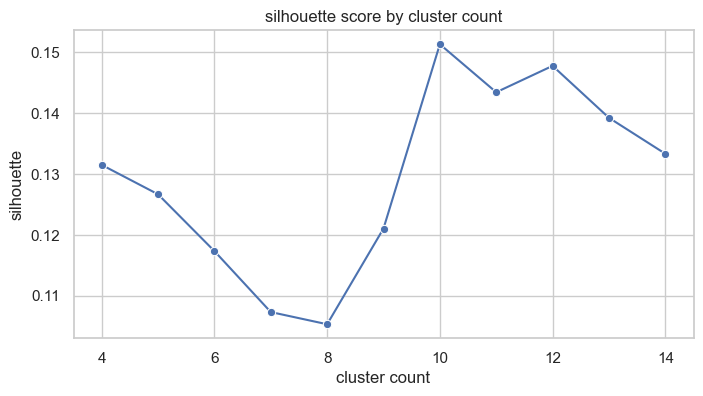

In [ ]:
def embed_texts(texts: list[str], batch_size: int = BATCH_SIZE) -> np.ndarray:
    client = OpenAI()
    embeddings = []

    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        response = client.embeddings.create(model=EMBEDDING_MODEL, input=batch)
        embeddings.extend(item.embedding for item in response.data)
        print(f"embedded {min(start + batch_size, len(texts))}/{len(texts)} prompts")

    return np.asarray(embeddings, dtype=float)


def load_or_create_embeddings(df: pd.DataFrame, fingerprint: str, rebuild: bool = False) -> np.ndarray:
    if EMBEDDINGS_CACHE_PATH.exists() and EMBEDDINGS_META_PATH.exists() and not rebuild:
        cached_meta = json.loads(EMBEDDINGS_META_PATH.read_text(encoding="utf-8"))
        if (
            cached_meta.get("fingerprint") == fingerprint
            and cached_meta.get("embedding_model") == EMBEDDING_MODEL
            and cached_meta.get("embedding_char_limit") == EMBEDDING_CHAR_LIMIT
        ):
            cached_embeddings = np.load(EMBEDDINGS_CACHE_PATH)
            assert len(cached_embeddings) == len(df), "cached embeddings do not match the current dataset; set REBUILD_EMBEDDINGS = True"
            return cached_embeddings

    embeddings = embed_texts(df["embedding_text"].tolist())
    np.save(EMBEDDINGS_CACHE_PATH, embeddings)
    EMBEDDINGS_META_PATH.write_text(
        json.dumps(
            {
                "fingerprint": fingerprint,
                "embedding_model": EMBEDDING_MODEL,
                "embedding_char_limit": EMBEDDING_CHAR_LIMIT,
                "n_rows": len(df),
            },
            indent=2,
        ),
        encoding="utf-8",
    )
    return embeddings


def sweep_cluster_counts(embeddings: np.ndarray, min_clusters: int, max_clusters: int) -> pd.DataFrame:
    normalized_embeddings = normalize(embeddings)
    records = []

    for cluster_count in range(min_clusters, max_clusters + 1):
        labels = AgglomerativeClustering(
            n_clusters=cluster_count,
            metric="cosine",
            linkage="average",
        ).fit_predict(normalized_embeddings)
        score = silhouette_score(normalized_embeddings, labels, metric="cosine")
        records.append({"n_clusters": cluster_count, "silhouette": score})

    return pd.DataFrame(records)


effective_max_clusters = min(MAX_CLUSTERS, len(analysis_ready_df) - 1)
effective_min_clusters = min(MIN_CLUSTERS, effective_max_clusters)
assert effective_max_clusters >= 2, "need at least 3 extracted prompts before clustering"

embeddings = load_or_create_embeddings(analysis_ready_df, fingerprint=analysis_fingerprint, rebuild=REBUILD_EMBEDDINGS)
cluster_search_df = sweep_cluster_counts(embeddings, effective_min_clusters, effective_max_clusters)
best_cluster_count = int(cluster_search_df.sort_values("silhouette", ascending=False).iloc[0]["n_clusters"])

print(f"best cluster count by silhouette: {best_cluster_count}")
display(cluster_search_df)

plt.figure(figsize=(8, 4))
sns.lineplot(data=cluster_search_df, x="n_clusters", y="silhouette", marker="o")
plt.title("silhouette score by cluster count")
plt.xlabel("cluster count")
plt.ylabel("silhouette")
plt.show()

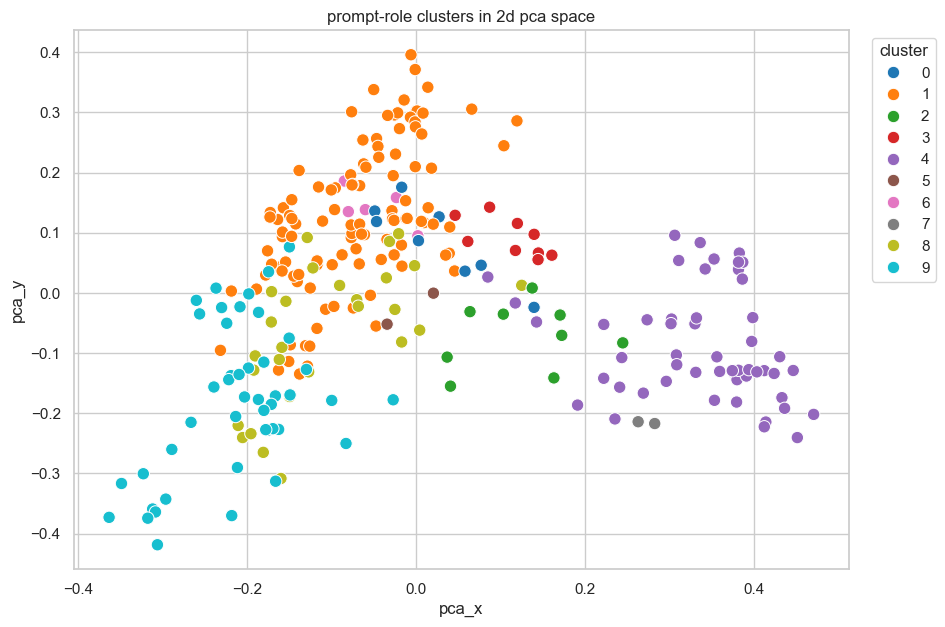

,cluster_id,size,sample_agents
1,1,109,"RESEARCH PLAN GENERATOR - Task Planning, RESEARCH RESULT WRITER - Result Compilation & Synthesis, RESEARCH TOOL SELECTOR - Tool Selection & Execution, CODER..."
4,4,52,"DATA ANALYSIS FILTER DOCUMENT - Document Selection & Filtering, DATA ANALYSIS MERGE SUMMARY - Multi-Document Summary Consolidation, DATA ANALYSIS SUMMARY DO..."
9,9,45,"BASE - AGENT ROLE TEMPLATE, BASE - DATA PREVIEW, BASE - EXPERIENCE WITH SUGGESTION, BASE - EXTRACT TOOLS"
8,8,27,"ROUTING - Question Router, DATA_CLEANING_AGENT - Create Data Cleaner Code, DATA_CLEANING_AGENT - Fix Data Cleaner Code, DATA_CLEANING_AGENT - Recommend Data..."
2,2,9,"BACKTEST_RUNNER, CHAT_AGENT, CLIPS_AGENT, CODE_RUNNER_AGENT"
3,3,9,"AGENT_PROMPT_BY_JSON - Product Search Agent (JSON Version), AGENT_PROMPT_BY_SUPERLINKED - Product Search Agent (Superlinked Version), AMAZON_SEARCH_PROMPT -..."
0,0,8,"MULTIQUERY - Multi-Perspective Question Generator, ARXIV SEARCH TOOL - Command Docstring, CHAT_QUESTION_GENERATOR, CHAT.PY - GitHub Search Optimization Expert"
6,6,5,"RAILS_AGENT_PROMPT (Rails Engineer/Product Advisor), RAILS_AI_BUILDER_AGENT_PROMPT (LangGraph Agent Architect), RAILS_FRONTEND_STARTER_AGENT_PROMPT (Front-E..."
5,5,2,"DEPENDENCY_ANALYSIS.PY - Hardware Compatibility Checker, PARSE_HARDWARE.PY - Hardware Constraint Extractor"
7,7,2,"FORMAT PRICE EXTRACTION - Price Parsing Helper, FORMAT SIZE EXTRACTION - Size Parsing Helper"


In [15]:
SELECTED_CLUSTER_COUNT = best_cluster_count


def attach_clusters(df: pd.DataFrame, embeddings: np.ndarray, cluster_count: int) -> tuple[pd.DataFrame, pd.DataFrame, np.ndarray]:
    normalized_embeddings = normalize(embeddings)
    labels = AgglomerativeClustering(
        n_clusters=cluster_count,
        metric="cosine",
        linkage="average",
    ).fit_predict(normalized_embeddings)

    clustered_df = df.copy()
    clustered_df["cluster_id"] = labels
    clustered_df["cluster_size"] = clustered_df.groupby("cluster_id")["cluster_id"].transform("size")
    clustered_df["prompt_preview"] = clustered_df["prompt_text"].map(lambda value: clip_text(value, 280))

    pca = PCA(n_components=2, random_state=42)
    coordinates = pca.fit_transform(normalized_embeddings)
    clustered_df["pca_x"] = coordinates[:, 0]
    clustered_df["pca_y"] = coordinates[:, 1]

    medoid_rows = []
    for cluster_id, group in clustered_df.groupby("cluster_id", sort=True):
        group_embeddings = normalized_embeddings[group.index.to_numpy()]
        centroid = group_embeddings.mean(axis=0)
        centroid = centroid / np.linalg.norm(centroid)
        medoid_offset = int(np.argmax(group_embeddings @ centroid))
        medoid_row = group.iloc[medoid_offset]
        medoid_rows.append(
            {
                "cluster_id": cluster_id,
                "medoid_repo_name": medoid_row["repo_name"],
                "medoid_agent_name": medoid_row["agent_name"],
                "medoid_prompt_preview": medoid_row["prompt_preview"],
            }
        )

    medoid_df = pd.DataFrame(medoid_rows)
    clustered_df = clustered_df.merge(medoid_df, on="cluster_id", how="left")
    return clustered_df, medoid_df, normalized_embeddings


clustered_df, medoid_df, normalized_embeddings = attach_clusters(
    analysis_ready_df,
    embeddings,
    SELECTED_CLUSTER_COUNT,
)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=clustered_df,
    x="pca_x",
    y="pca_y",
    hue="cluster_id",
    palette="tab10",
    s=80,
)
plt.title("prompt-role clusters in 2d pca space")
plt.legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

display(
    clustered_df.groupby("cluster_id", as_index=False)
    .agg(size=("agent_name", "size"), sample_agents=("agent_name", lambda values: ", ".join(values.head(4))))
    .sort_values("size", ascending=False)
)

In [ ]:
LABEL_SYSTEM_PROMPT = """
you are labeling clusters of system prompts from multi-agent repositories.

given the examples in one cluster, produce a concise, human-readable centroid for product and research use.

return json only in the shape:
{
  "cluster_name": "short label, 1 to 3 words",
  "centroid_summary": "one sentence describing the shared role of this cluster",
  "guided_start_description": "one sentence describing how this role could be presented in a guided start ui"
}
""".strip()


def cluster_component_snapshot(group: pd.DataFrame) -> list[str]:
    component_rates = group[COMPONENT_COLUMNS].mean().sort_values(ascending=False)
    return [
        f"{component_label(name)} ({rate:.0%})"
        for name, rate in component_rates.items()
        if rate >= COMPONENT_MIN_RATE
    ]


def label_cluster_with_llm(client: OpenAI, cluster_id: int, group: pd.DataFrame) -> dict:
    sample_df = group.sort_values("prompt_chars", ascending=False).head(6)
    payload = {
        "cluster_id": int(cluster_id),
        "size": int(len(group)),
        "representative_agents": [
            {
                "repo_name": row["repo_name"],
                "agent_name": row["agent_name"],
                "prompt_preview": clip_text(row["prompt_text"], 700),
            }
            for _, row in sample_df.iterrows()
        ],
        "medoid": {
            "repo_name": group.iloc[0]["medoid_repo_name"],
            "agent_name": group.iloc[0]["medoid_agent_name"],
            "prompt_preview": group.iloc[0]["medoid_prompt_preview"],
        },
        "common_components": cluster_component_snapshot(group),
    }
    response = client.chat.completions.create(
        model=LABEL_MODEL,
        temperature=0.2,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": LABEL_SYSTEM_PROMPT},
            {"role": "user", "content": json.dumps(payload)},
        ],
    )
    content = response.choices[0].message.content
    assert content, f"empty cluster label response for cluster {cluster_id}"
    parsed = json.loads(content)
    required_keys = {"cluster_name", "centroid_summary", "guided_start_description"}
    assert required_keys.issubset(parsed), f"invalid label payload for cluster {cluster_id}"
    parsed["cluster_id"] = int(cluster_id)
    return parsed


def load_or_create_cluster_labels(df: pd.DataFrame, rebuild: bool = False) -> pd.DataFrame:
    cluster_fingerprint = fingerprint_records(
        df.sort_values(["cluster_id", "repo_name", "agent_name"])[["cluster_id", "repo_name", "agent_name"]],
        ["cluster_id", "repo_name", "agent_name"],
    )
    cached_bundle = json.loads(LABELS_CACHE_PATH.read_text(encoding="utf-8")) if LABELS_CACHE_PATH.exists() and not rebuild else {}
    label_cache = {}
    if (
        cached_bundle.get("fingerprint") == cluster_fingerprint
        and cached_bundle.get("label_model") == LABEL_MODEL
    ):
        label_cache = cached_bundle.get("labels", {})
    client = OpenAI()

    for cluster_id, group in df.groupby("cluster_id", sort=True):
        cache_key = str(int(cluster_id))
        if cache_key in label_cache:
            continue
        print(f"labeling cluster {cluster_id}")
        label_cache[cache_key] = label_cluster_with_llm(client, cluster_id, group)
        LABELS_CACHE_PATH.write_text(
            json.dumps(
                {
                    "fingerprint": cluster_fingerprint,
                    "cluster_count": int(df["cluster_id"].nunique()),
                    "label_model": LABEL_MODEL,
                    "labels": label_cache,
                },
                indent=2,
            ),
            encoding="utf-8",
        )

    label_df = pd.DataFrame(label_cache.values()).sort_values("cluster_id").reset_index(drop=True)
    return label_df


cluster_label_df = load_or_create_cluster_labels(clustered_df, rebuild=REBUILD_CLUSTER_LABELS)
clustered_df = clustered_df.merge(cluster_label_df, on="cluster_id", how="left")
clustered_df["cluster_display_name"] = clustered_df["cluster_id"].astype(str) + ": " + clustered_df["cluster_name"]

cluster_overview_df = (
    clustered_df.groupby(
        [
            "cluster_id",
            "cluster_name",
            "centroid_summary",
            "guided_start_description",
            "medoid_repo_name",
            "medoid_agent_name",
        ],
        as_index=False,
    )
    .agg(
        size=("agent_name", "size"),
        repos=("repo_name", lambda values: ", ".join(sorted(set(values)))),
        sample_agents=("agent_name", lambda values: ", ".join(values.head(5))),
    )
    .sort_values(["size", "cluster_name"], ascending=[False, True])
)

cluster_assignments_export_columns = [
    "repo_name",
    "agent_name",
    "cluster_id",
    "cluster_name",
    "cluster_display_name",
    "centroid_summary",
    "guided_start_description",
    "cluster_size",
    "prompt_chars",
    "prompt_preview",
] + COMPONENT_COLUMNS
clustered_df[cluster_assignments_export_columns].to_csv(OUTPUT_DIR / "cluster_assignments.csv", index=False)
cluster_overview_df.to_csv(OUTPUT_DIR / "cluster_overview.csv", index=False)

display(cluster_overview_df)

labeling cluster 0
labeling cluster 1
labeling cluster 2
labeling cluster 3
labeling cluster 4
labeling cluster 5
labeling cluster 6
labeling cluster 7
labeling cluster 8
labeling cluster 9


,cluster_id,cluster_name,centroid_summary,guided_start_description,medoid_repo_name,medoid_agent_name,size,repos,sample_agents
1,1,Research Coordinator,"These prompts define agents that plan, gather, evaluate, synthesize, and finalize evidence-based research or analysis workflows, often coordinating multi-st...","Use this agent to run a structured research process that searches for information, identifies gaps, and produces a reliable final report or analysis.",LeapLabTHU_cooragent,RESEARCHER,109,"FinStep-AI_ContestTrade, InternScience, LeapLabTHU_cooragent, NL2Code_CodeR, SalesforceAIResearch_enterprise-deep-research, SamuelSchmidgall_AgentLaboratory...","RESEARCH PLAN GENERATOR - Task Planning, RESEARCH RESULT WRITER - Result Compilation & Synthesis, RESEARCH TOOL SELECTOR - Tool Selection & Execution, CODER..."
4,4,Trading Analysts,"Agents in this cluster analyze market, chart, sentiment, and risk signals to recommend or debate concrete trading actions such as buy, sell, hold, long, or ...",Use this role when you want an AI trading specialist to evaluate financial or prediction market data and produce a clear trade recommendation or risk-based ...,TauricResearch_TradingAgents,TRADER - Final Investment Decision Making,52,"FinStep-AI_ContestTrade, HKUDS_AI-Trader, Polymarket_agents, TauricResearch_TradingAgents, Y-Research-SBU_QuantAgent, moondevonyt_moon-dev-ai-agents","DATA ANALYSIS FILTER DOCUMENT - Document Selection & Filtering, DATA ANALYSIS MERGE SUMMARY - Multi-Document Summary Consolidation, DATA ANALYSIS SUMMARY DO..."
9,9,Workflow Orchestrators,"Prompts in this cluster define structured, phase-aware workflow roles that plan, execute, summarize, review, or validate work using explicit inputs, constra...","Use this role when you want an agent to operate as a step in a larger pipeline, with clear phase context, prescribed tasks, and standardized deliverables.",multimodal-art-projection_AutoKaggle,DEVELOPER - MAIN PROMPT,45,multimodal-art-projection_AutoKaggle,"BASE - AGENT ROLE TEMPLATE, BASE - DATA PREVIEW, BASE - EXPERIENCE WITH SUGGESTION, BASE - EXTRACT TOOLS, BASE - FEATURE INFO"
8,8,Data Science,"Agents in this cluster perform or coordinate practical data science workflows such as data loading, wrangling, feature engineering, visualization planning, ...","Use this role when you want an AI teammate to help route, prepare, analyze, visualize, or model tabular data in an end-to-end data science workflow.",business-science_ai-data-science-team,DATA_WRANGLING_AGENT - Create Data Wrangler Code,27,"Polymarket_agents, business-science_ai-data-science-team","ROUTING - Question Router, DATA_CLEANING_AGENT - Create Data Cleaner Code, DATA_CLEANING_AGENT - Fix Data Cleaner Code, DATA_CLEANING_AGENT - Recommend Data..."
3,3,Product Search,"Agents in this cluster help users find products by searching a product database, judging result relevance, and responding clearly when matches are weak or u...","Use this assistant to search for products, evaluate which results best match a shopper’s request, and explain next steps when no exact items are found.",Deluxer_oliva,AGENT_PROMPT_BY_SUPERLINKED - Product Search Agent (Superlinked Version),9,Deluxer_oliva,"AGENT_PROMPT_BY_JSON - Product Search Agent (JSON Version), AGENT_PROMPT_BY_SUPERLINKED - Product Search Agent (Superlinked Version), AMAZON_SEARCH_PROMPT -..."
2,2,Utility Assistants,"This cluster contains narrowly scoped helper agents that perform specific support tasks such as answering from a knowledge base, checking compliance, summar...","Use this role when you want a lightweight task-specific assistant for a single workflow step like Q&A, review, rating, or short-form content generation.",moondevonyt_moon-dev-ai-agents,MILLION_AGENT,9,moondevonyt_moon-dev-ai-agents,"BACKTEST_RUNNER, CHAT_AGENT, CLIPS_AGENT, CODE_RUNNER_AGENT, COMPLIANCE_AGENT"
0,0,Search Helpers,"Agents in this cluster perform narrow retrieval-support tasks such as generating search tags, filtering whethe

,cluster_id,cluster_name,component_label,cluster_rate,lift
10,0,Search Helpers,task description workflow,1.000000,1.089431
8,0,Search Helpers,role description,0.875000,1.127404
7,0,Search Helpers,placeholder,0.875000,1.122010
1,0,Search Helpers,constraints restrictions,0.875000,1.065909
6,0,Search Helpers,output,0.875000,1.065909
5,0,Search Helpers,input,0.875000,1.051570
22,1,Research Coordinator,task description workflow,1.000000,1.089431
13,1,Research Coordinator,constraints restrictions,0.990826,1.207006
20,1,Research Coordinator,role description,0.972477,1.252999
18,1,Research Coordinator,output,0.926606,1.128774


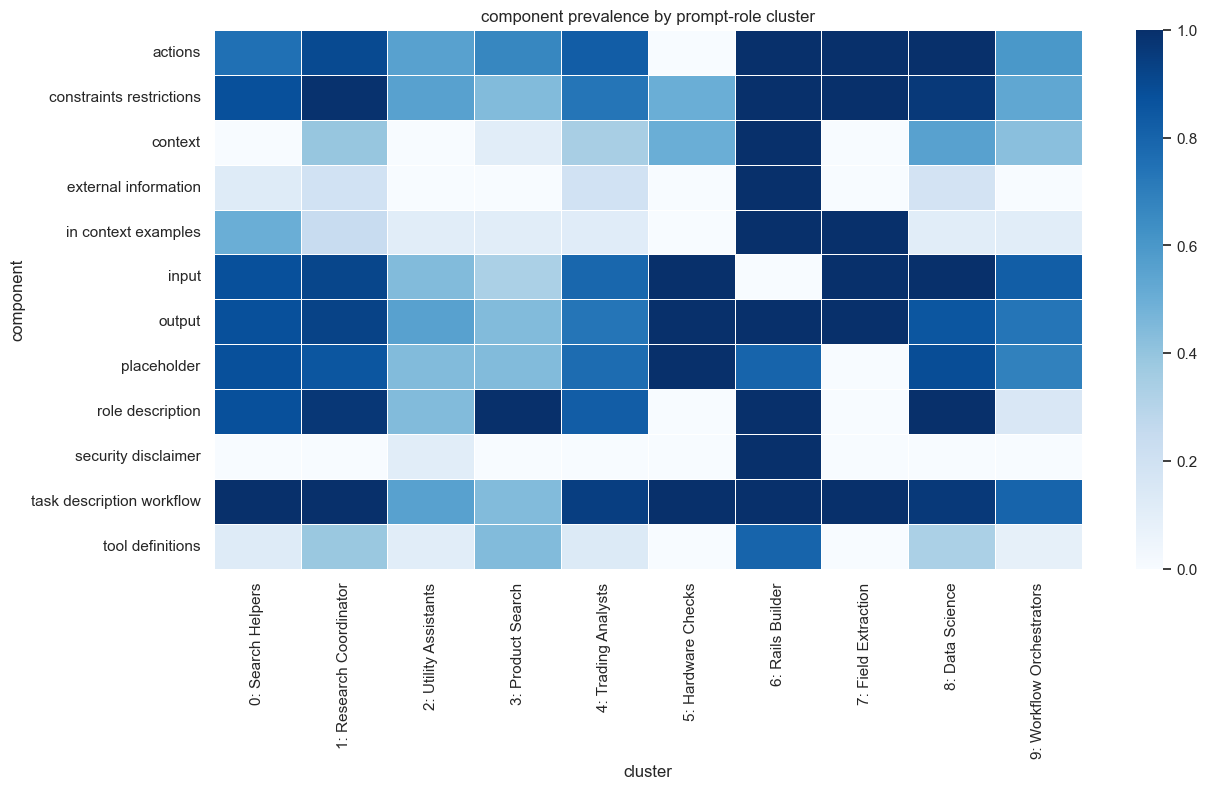

,cluster_id,cluster_name,cluster_display_name,centroid_summary,guided_start_description,size,source_repos,representative_agents,medoid_agent,common_components
0,0,Search Helpers,0: Search Helpers,"Agents in this cluster perform narrow retrieval-support tasks such as generating search tags, filtering whether deeper analysis is needed, querying research...","Use this assistant when you want help turning a request into search terms, lightweight retrieval decisions, concise match explanations, or short queryable o...",8,"[Polymarket_agents, SamuelSchmidgall_AgentLaboratory, moondevonyt_moon-dev-ai-agents, zamalali_DeepGit]","[{'repo_name': 'zamalali_DeepGit', 'agent_name': 'CHAT.PY - GitHub Search Optimization Expert', 'prompt_preview': 'System Role: ""You are a GitHub search opt...","{'repo_name': 'zamalali_DeepGit', 'agent_name': 'CHAT.PY - GitHub Search Optimization Expert'}","[task description workflow, role description, placeholder, constraints restrictions, output, input]"
1,1,Research Coordinator,1: Research Coordinator,"These prompts define agents that plan, gather, evaluate, synthesize, and finalize evidence-based research or analysis workflows, often coordinating multi-st...","Use this agent to run a structured research process that searches for information, identifies gaps, and produces a reliable final report or analysis.",109,"[FinStep-AI_ContestTrade, InternScience, LeapLabTHU_cooragent, NL2Code_CodeR, SalesforceAIResearch_enterprise-deep-research, SamuelSchmidgall_AgentLaborator...","[{'repo_name': 'SalesforceAIResearch_enterprise-deep-research', 'agent_name': 'finalize_report_instructions', 'prompt_preview': '<TIME_CONTEXT> Current date...","{'repo_name': 'LeapLabTHU_cooragent', 'agent_name': 'RESEARCHER'}","[task description workflow, constraints restrictions, role description, output, input, actions, placeholder]"
2,2,Utility Assistants,2: Utility Assistants,"This cluster contains narrowly scoped helper agents that perform specific support tasks such as answering from a knowledge base, checking compliance, summar...","Use this role when you want a lightweight task-specific assistant for a single workflow step like Q&A, review, rating, or short-form content generation.",9,[moondevonyt_moon-dev-ai-agents],"[{'repo_name': 'moondevonyt_moon-dev-ai-agents', 'agent_name': 'COMPLIANCE_AGENT', 'prompt_preview': 'COMPLIANCE_AGENT - Moon Dev's Compliance Agent System ...","{'repo_name': 'moondevonyt_moon-dev-ai-agents', 'agent_name': 'MILLION_AGENT'}",[]
3,3,Product Search,3: Product Search,"Agents in this cluster help users find products by searching a product database, judging result relevance, and responding clearly when matches are weak or u...","Use this assistant to search for products, evaluate which results best match a shopper’s request, and explain next steps when no exact items are found.",9,[Deluxer_oliva],"[{'repo_name': 'Deluxer_oliva', 'agent_name': 'SUPERVISOR_SYSTEM_PROMPT - Supervisor Agent (Dynamic Generation)', 'prompt_preview': 'Dynamic prompt generate...","{'repo_name': 'Deluxer_oliva', 'agent_name': 'AGENT_PROMPT_BY_SUPERLINKED - Product Search Agent (Superlinked Version)'}",[role description]
4,4,Trading Analysts,4: Trading Analysts,"Agents in this cluster analyze market, chart, sentiment, and risk signals to recommend or debate concrete trading actions such as buy, sell, hold, long, or ...",Use this role when you want an AI trading specialist to evaluate financial or prediction market data and produce a clear trade recommendation or risk-based ...,52,"[FinStep-AI_ContestTrade, HKUDS_AI-Trader, Polymarket_agents, TauricResearch_TradingAgents, Y-Research-SBU_QuantAgent, moondevonyt_moon-dev-ai-agents]","[{'repo_name': 'TauricResearch_TradingAgents', 'agent_name': 'MARKET ANALYST - Technical Market Analysis', 'prompt_preview': 'System Role: ""You are a helpfu...","{'repo_name': 'TauricResearch_TradingAgents', 'agent_name': 'TRADER - Final Investment Decision Making'}",[role description]
5,5,Hardware C

guided start catalog: 4 roles (from clusters with size > 10)
  Research Coordinator (109 agents): task (100%), constraints (99%), role (97%), outputs (93%), inputs (92%), goal (90%)
  Trading Analysts (52 agents): task (94%), role (83%), goal (83%), inputs (79%), constraints (73%), outputs (73%)
  Data Science (27 agents): role (100%), goal (100%), inputs (100%), constraints (96%), task (96%), outputs (85%)
  Workflow Orchestrators (45 agents): inputs (82%), task (80%), outputs (73%), goal (60%)


In [17]:
global_component_rates = clustered_df[COMPONENT_COLUMNS].mean()
component_profiles_df = (
    clustered_df.melt(
        id_vars=["cluster_id", "cluster_name", "cluster_display_name"],
        value_vars=COMPONENT_COLUMNS,
        var_name="component",
        value_name="present",
    )
    .groupby(["cluster_id", "cluster_name", "cluster_display_name", "component"], as_index=False)["present"]
    .mean()
    .rename(columns={"present": "cluster_rate"})
)
component_profiles_df["global_rate"] = component_profiles_df["component"].map(global_component_rates)
component_profiles_df["lift"] = component_profiles_df["cluster_rate"] / component_profiles_df["global_rate"].replace(0, np.nan)
component_profiles_df["component_label"] = component_profiles_df["component"].map(component_label)
component_profiles_df = component_profiles_df.sort_values(["cluster_id", "cluster_rate", "lift"], ascending=[True, False, False])
component_profiles_df.to_csv(OUTPUT_DIR / "cluster_component_profiles.csv", index=False)

common_components_df = component_profiles_df.loc[
    (component_profiles_df["cluster_rate"] >= COMPONENT_MIN_RATE)
    & (component_profiles_df["lift"] >= COMPONENT_MIN_LIFT)
].copy()

display(common_components_df[["cluster_id", "cluster_name", "component_label", "cluster_rate", "lift"]])

heatmap_df = component_profiles_df.pivot(index="component_label", columns="cluster_display_name", values="cluster_rate")
plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_df, cmap="Blues", linewidths=0.5)
plt.title("component prevalence by prompt-role cluster")
plt.xlabel("cluster")
plt.ylabel("component")
plt.show()

cluster_cards = []
for cluster_id, group in clustered_df.groupby("cluster_id", sort=True):
    label_row = cluster_label_df.loc[cluster_label_df["cluster_id"] == cluster_id].iloc[0]
    representative_group = group.sort_values("prompt_chars", ascending=False).head(6)
    cluster_common_components = (
        common_components_df.loc[common_components_df["cluster_id"] == cluster_id, "component_label"]
        .tolist()
    )
    cluster_cards.append(
        {
            "cluster_id": int(cluster_id),
            "cluster_name": label_row["cluster_name"],
            "cluster_display_name": group.iloc[0]["cluster_display_name"],
            "centroid_summary": label_row["centroid_summary"],
            "guided_start_description": label_row["guided_start_description"],
            "size": int(len(group)),
            "source_repos": sorted(set(group["repo_name"])),
            "representative_agents": representative_group[["repo_name", "agent_name", "prompt_preview"]].to_dict("records"),
            "medoid_agent": {
                "repo_name": group.iloc[0]["medoid_repo_name"],
                "agent_name": group.iloc[0]["medoid_agent_name"],
            },
            "common_components": cluster_common_components,
        }
    )

(OUTPUT_DIR / "guided_start_cluster_cards.json").write_text(
    json.dumps(cluster_cards, indent=2),
    encoding="utf-8",
)

display(pd.DataFrame(cluster_cards))

# --- new guided start catalog for the playground UI ---

GUIDED_MIN_CLUSTER_SIZE = 10

# map notebook component column names to playground PromptComponentType values
COMPONENT_TYPE_MAP = {
    "role_description": "role",
    "task_description_workflow": "task",
    "actions": "goal",
    "constraints_restrictions": "constraints",
    "input": "inputs",
    "output": "outputs",
    "in_context_examples": "examples",
    "security_disclaimer": "safety",
    "tool_definitions": "tool_instructions",
    "external_information": "external_information",
    "context": "external_information",  # merged with external_information, take max
}
# placeholder is excluded — it tracks variable usage, not a component type

def slugify(text: str) -> str:
    return text.lower().replace(" ", "-").replace("_", "-")

catalog_roles = []
for cluster_id, group in clustered_df.groupby("cluster_id", sort=True):
    size = len(group)
    if size <= GUIDED_MIN_CLUSTER_SIZE:
        continue

    label_row = cluster_label_df.loc[cluster_label_df["cluster_id"] == cluster_id].iloc[0]
    cluster_profiles = component_profiles_df.loc[
        component_profiles_df["cluster_id"] == cluster_id
    ]

    # map and merge component rates into playground types
    mapped_rates: dict[str, float] = {}
    for _, row in cluster_profiles.iterrows():
        notebook_col = row["component"]
        playground_type = COMPONENT_TYPE_MAP.get(notebook_col)
        if playground_type is None:
            continue
        current_rate = mapped_rates.get(playground_type, 0.0)
        mapped_rates[playground_type] = max(current_rate, row["cluster_rate"])

    # keep components with prevalence >= 0.60, sorted descending
    components = [
        {
            "component_type": comp_type,
            "prevalence": round(rate, 2),
            "placeholder": "",
        }
        for comp_type, rate in sorted(mapped_rates.items(), key=lambda x: -x[1])
        if rate >= COMPONENT_MIN_RATE
    ]

    catalog_roles.append({
        "role_id": slugify(label_row["cluster_name"]),
        "name": label_row["cluster_name"],
        "summary": label_row["guided_start_description"],
        "sample_size": int(size),
        "components": components,
    })

guided_start_catalog = {
    "version": pd.Timestamp.now(tz="UTC").strftime("%Y-%m-%d"),
    "generated_at": pd.Timestamp.now(tz="UTC").isoformat(),
    "roles": catalog_roles,
}

(OUTPUT_DIR / "guided_start_catalog.json").write_text(
    json.dumps(guided_start_catalog, indent=2),
    encoding="utf-8",
)

print(f"guided start catalog: {len(catalog_roles)} roles (from clusters with size > {GUIDED_MIN_CLUSTER_SIZE})")
for role in catalog_roles:
    comp_summary = ", ".join(f'{c["component_type"]} ({c["prevalence"]:.0%})' for c in role["components"])
    print(f"  {role['name']} ({role['sample_size']} agents): {comp_summary}")

## how to use the outputs

- `cluster_overview.csv` is the easiest human review surface for deciding whether the clusters make sense
- `cluster_component_profiles.csv` shows which coded components are common inside each role family and how enriched they are versus the full corpus
- `guided_start_cluster_cards.json` is the cleanest starting point for frontend seeding because it includes a label, centroid summary, example agents, and common components for each cluster

if you want to iterate further, the two highest leverage knobs are:

1. the prompt reconstruction prompt in the extraction cell
2. the clustering range and thresholds (`MIN_CLUSTERS`, `MAX_CLUSTERS`, `COMPONENT_MIN_RATE`, `COMPONENT_MIN_LIFT`)

for source-of-truth use, it is worth manually reviewing cluster labels and a few medoid prompts before wiring the export into the guided start ui.